In [1]:
# ===============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pruebas estadísticas para validar PCA
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

In [2]:
# ===============================
# 2. CARGA DEL DATASET
# ===============================

df = pd.read_csv("movies_2026.csv", encoding="latin1")

df.head()

,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0
3,1626808,0.0,Thriller|Mystery|Documentary,NaN,NaN,NaN,NaN,0.0,5,False,...,2026-02-01,0.0,0,3,0,0,7,0.0,0.0,2026.0
4,1626678,0.0,Animation,NaN,NaN,NaN,NaN,0.0,12,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [3]:
# ===============================
# 3. SELECCIÓN DE VARIABLES NUMÉRICAS
# ===============================

df_num = df.select_dtypes(include=['int64', 'float64'])

# Eliminar id porque no aporta información
if 'id' in df_num.columns:
    df_num = df_num.drop(columns=['id'])

print("Variables numéricas utilizadas:")
df_num.columns

Variables numéricas utilizadas:


Index(['budget', 'revenue', 'runtime', 'popularity', 'voteAvg', 'voteCount',
       'genresAmount', 'productionCoAmount', 'productionCountriesAmount',
       'actorsAmount', 'castWomenAmount', 'castMenAmount', 'releaseYear'],
      dtype='str')

In [4]:
# ===============================
# 4. MANEJO DE VALORES NULOS
# ===============================

print("Valores nulos por variable:")
print(df_num.isnull().sum())

# Eliminamos filas con nulos
df_num = df_num.dropna()

print("Dimensiones después de eliminar nulos:", df_num.shape)

Valores nulos por variable:
budget                         0
revenue                        0
runtime                        0
popularity                     0
voteAvg                        0
voteCount                      0
genresAmount                   0
productionCoAmount             0
productionCountriesAmount      0
actorsAmount                   0
castWomenAmount               37
castMenAmount                162
releaseYear                    2
dtype: int64
Dimensiones después de eliminar nulos: (19719, 13)


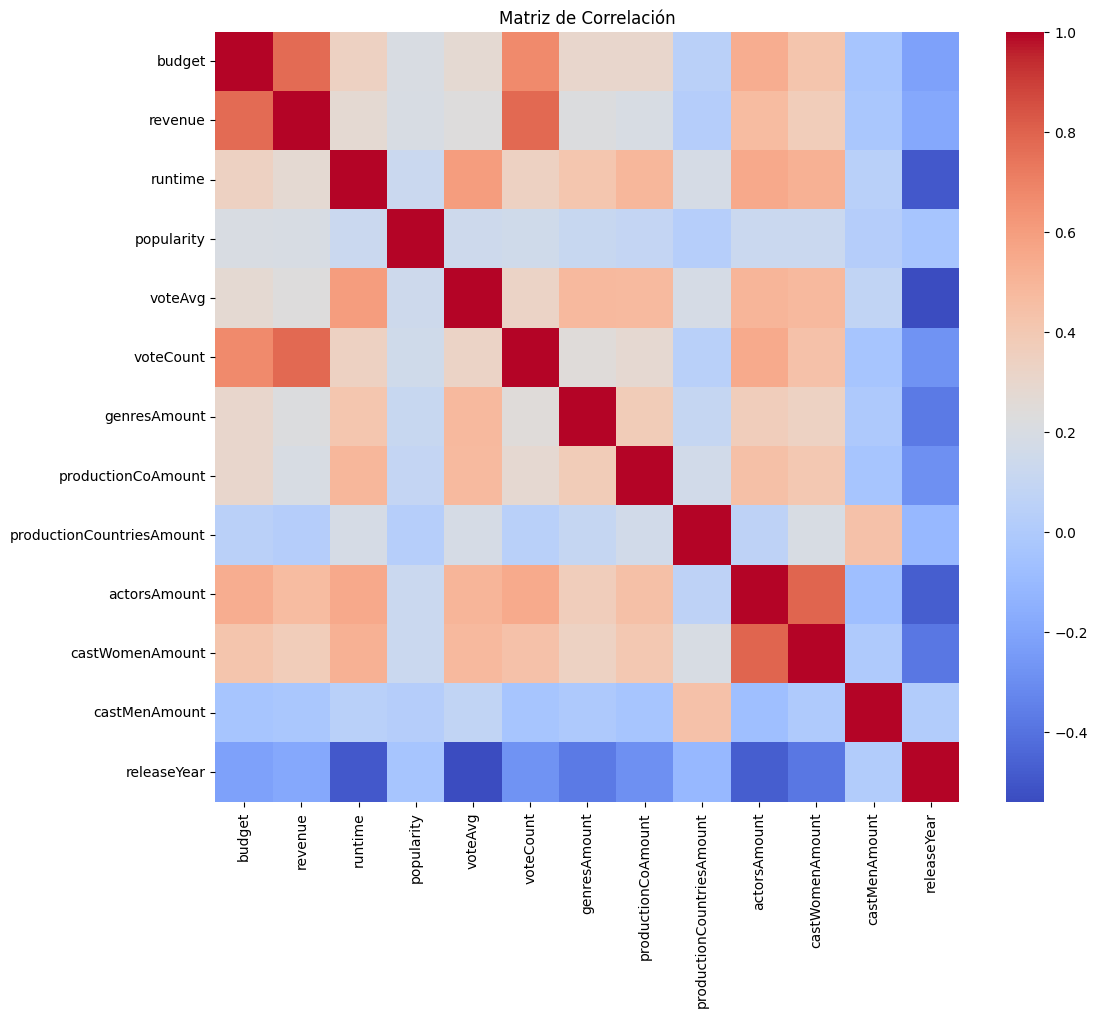

In [5]:
# ===============================
# 5. MATRIZ DE CORRELACIÓN
# ===============================

plt.figure(figsize=(12,10))
sns.heatmap(df_num.corr(), cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

In [6]:
# ===============================
# 6. PRUEBA KMO
# ===============================

kmo_all, kmo_model = calculate_kmo(df_num)
print("KMO:", kmo_model)

KMO: 0.8353831631592203


In [7]:
# ===============================
# 7. TEST DE ESFERICIDAD DE BARTLETT
# ===============================

chi_square_value, p_value = calculate_bartlett_sphericity(df_num)

print("Chi-cuadrado:", chi_square_value)
print("p-value:", p_value)

Chi-cuadrado: 115646.62683422635
p-value: 0.0


In [8]:
# ===============================
# 8. ESCALAMIENTO DE DATOS
# ===============================

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

In [10]:
# ===============================
# 9. APLICACIÓN DEL PCA
# ===============================

pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_

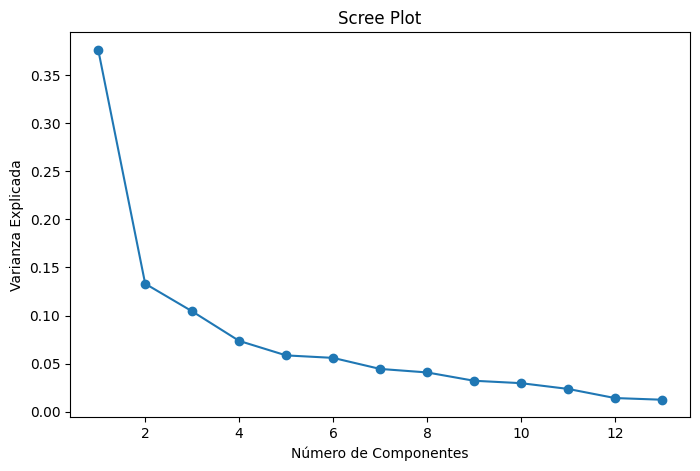

In [11]:
# ===============================
# 10. SCREE PLOT
# ===============================

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')
plt.title('Scree Plot')
plt.show()

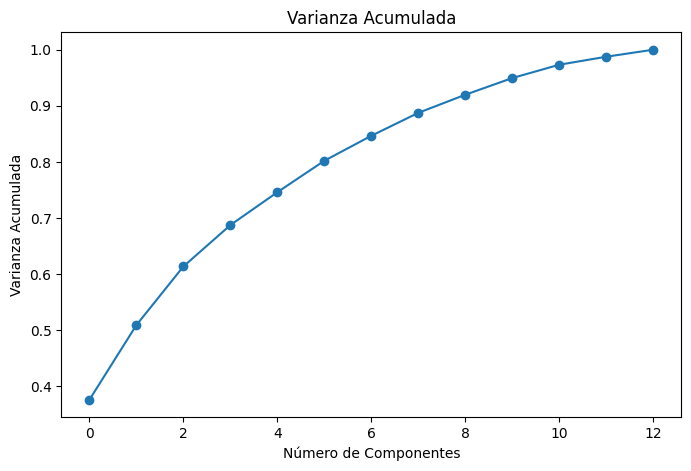

In [12]:
# ===============================
# 11. VARIANZA ACUMULADA
# ===============================

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada')
plt.show()

In [13]:
# ===============================
# 12. SELECCIÓN DE COMPONENTES
# ===============================

var_acumulada = np.cumsum(explained_variance)

n_componentes = np.argmax(var_acumulada >= 0.80) + 1

print("Número de componentes seleccionados:", n_componentes)

pca_final = PCA(n_components=n_componentes)
principal_components = pca_final.fit_transform(df_scaled)

Número de componentes seleccionados: 6


In [14]:
# ===============================
# 13. INTERPRETACIÓN DE COMPONENTES
# ===============================

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(n_componentes)],
    index=df_num.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
budget,0.317591,0.374853,0.184288,-0.033435,0.146339,0.110544
revenue,0.296062,0.449611,0.240745,-0.073789,0.184321,-0.008897
runtime,0.330201,-0.237072,-0.103228,0.029171,-0.052254,-0.012084
popularity,0.108472,0.108374,0.164757,0.926107,-0.218600,-0.170695
voteAvg,0.320402,-0.297108,-0.107519,0.101019,0.153213,-0.113093
voteCount,0.322250,0.360771,0.165543,-0.131059,0.113072,-0.031185
genresAmount,0.260002,-0.180990,-0.149739,0.184765,0.598901,0.180720
productionCoAmount,0.273419,-0.193172,-0.136356,0.090329,-0.079937,0.706981
productionCountriesAmount,0.090765,-0.376183,0.557976,-0.096924,-0.106314,0.175147
actorsAmount,0.376069,0.035528,-0.109227,-0.150959,-0.378068,-0.105396


In [15]:
# ===============================
# 13. INTERPRETACIÓN DE COMPONENTES
# ===============================

loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(n_componentes)],
    index=df_num.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
budget,0.317591,0.374853,0.184288,-0.033435,0.146339,0.110544
revenue,0.296062,0.449611,0.240745,-0.073789,0.184321,-0.008897
runtime,0.330201,-0.237072,-0.103228,0.029171,-0.052254,-0.012084
popularity,0.108472,0.108374,0.164757,0.926107,-0.218600,-0.170695
voteAvg,0.320402,-0.297108,-0.107519,0.101019,0.153213,-0.113093
voteCount,0.322250,0.360771,0.165543,-0.131059,0.113072,-0.031185
genresAmount,0.260002,-0.180990,-0.149739,0.184765,0.598901,0.180720
productionCoAmount,0.273419,-0.193172,-0.136356,0.090329,-0.079937,0.706981
productionCountriesAmount,0.090765,-0.376183,0.557976,-0.096924,-0.106314,0.175147
actorsAmount,0.376069,0.035528,-0.109227,-0.150959,-0.378068,-0.105396
